## Exploratory Data Analysis 

All 4 portfolio - A, B, C, D | Daily + Interval data | April–June 2025 (interval), Jan 2024–Aug 2025 (daily)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
from datetime import datetime
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

PORTFOLIOS = ['A', 'B', 'C', 'D']
FILE       = Path('data.xlsx')

In [8]:
def parse_date(raw):
    if raw is None: return None
    if isinstance(raw, (pd.Timestamp, datetime)): return pd.Timestamp(raw).date()
    if isinstance(raw, float) and np.isnan(raw): return None
    try: return datetime.strptime(str(raw).strip().split()[0], '%m/%d/%y').date()
    except: return None

def to_mins(val):
    if hasattr(val, 'hour'): return int(val.hour * 60 + val.minute)
    if isinstance(val, float):
        if np.isnan(val): return None
        return int(round(val * 24 * 60))
    if isinstance(val, str):
        try: p = val.strip().split(':'); return int(p[0]) * 60 + int(p[1])
        except: return None
    return None

MONTH_MAP = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
DOW_MAP   = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
COLORS    = {'A':'#378ADD','B':'#1D9E75','C':'#BA7517','D':'#993556'}


FORECAST_CSV    = Path('outputs/forecast_v39.csv')
ALL_SLOTS       = list(range(0, 1440, 30))
SLOT_LABELS     = [f"{m//60}:{m%60:02d}" for m in ALL_SLOTS]
TRAINING_MONTHS = [4, 5, 6]
MONTH_TO_NUM    = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
                   'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
MONTH_NAMES     = {v: k for k, v in MONTH_TO_NUM.items()}


def load_daily_pres(p):
    df = pd.read_excel(FILE, sheet_name=f'{p} - Daily', engine='openpyxl')
    df.columns = df.columns.str.strip()
    df['date']         = df[df.columns[0]].apply(parse_date)
    df = df.dropna(subset=['date']).copy()
    df['year']         = df['date'].apply(lambda d: d.year)
    df['month_num']    = df['date'].apply(lambda d: d.month)
    df['day_of_month'] = df['date'].apply(lambda d: d.day)
    df['dow']          = df['date'].apply(lambda d: d.weekday())
    return df.sort_values('date').reset_index(drop=True)

def load_interval_pres(p):
    df = pd.read_excel(FILE, sheet_name=f'{p} - Interval', engine='openpyxl')
    df.columns = df.columns.str.strip()
    df = df.rename(columns={'Month':'month_name','Day':'day_of_month','Interval':'interval_raw'})
    df['mins']      = df['interval_raw'].apply(to_mins)
    df['month_num'] = df['month_name'].map(MONTH_TO_NUM)
    df = df[df['mins'].notna()].copy()
    df['mins'] = df['mins'].astype(int)
    return df.sort_values(['month_num','day_of_month','mins']).reset_index(drop=True)

In [9]:
daily    = {}
interval = {}

for p in PORTFOLIOS:
    d = pd.read_excel(FILE, sheet_name=f'{p} - Daily', engine='openpyxl')
    d.columns = d.columns.str.strip()
    d['date']         = d[d.columns[0]].apply(parse_date)
    d = d.dropna(subset=['date'])
    d['year']         = d['date'].apply(lambda x: x.year)
    d['month']        = d['date'].apply(lambda x: x.month)
    d['day_of_month'] = d['date'].apply(lambda x: x.day)
    d['dow']          = d['date'].apply(lambda x: x.weekday())
    d['dow_name']     = d['dow'].map(DOW_MAP)
    daily[p] = d.sort_values('date').reset_index(drop=True)

    iv = pd.read_excel(FILE, sheet_name=f'{p} - Interval', engine='openpyxl')
    iv.columns = iv.columns.str.strip()
    iv = iv.rename(columns={iv.columns[0]:'Month', iv.columns[1]:'Day',
                             iv.columns[2]:'Interval_raw'})
    iv['mins']      = pd.to_numeric(iv['Interval_raw'].apply(to_mins), errors='coerce')
    iv['month_num'] = iv['Month'].map(MONTH_MAP)
    interval[p] = iv.sort_values(['month_num','Day','mins']).reset_index(drop=True)

print(f'{'Portfolio':<12} {'Daily rows':>12} {'Interval rows':>15}')
for p in PORTFOLIOS:
    print(f'{p:<12} {len(daily[p]):>12,} {len(interval[p]):>15,}')

Portfolio      Daily rows   Interval rows
A                     731           4,083
B                     731           4,293
C                     731           4,368
D                     731           4,358


In [ ]:
iv_train = {}
for p in PORTFOLIOS:
    iv = interval[p][interval[p]['month_num'].isin(TRAINING_MONTHS)].copy() if 'month_num' in interval[p].columns else interval[p][interval[p]['Month'].map(MONTH_MAP).isin(TRAINING_MONTHS)].copy()
  
    d_lk = (daily[p][(daily[p]['year']==2025) & daily[p]['month'].isin(TRAINING_MONTHS)]
             .set_index(['month','day_of_month'])['Call Volume'].to_dict())
    
    mn_col = 'month_num' if 'month_num' in iv.columns else None
    if mn_col is None:
        iv['month_num'] = iv['Month'].map(MONTH_MAP)
    iv['cv_daily'] = iv.apply(
        lambda r: d_lk.get((int(r['month_num']), int(r['Day'] if 'Day' in iv.columns else r['day_of_month'])), float('nan')), axis=1)
    iv = iv.dropna(subset=['cv_daily','Call Volume'])
    iv['cv_frac'] = (iv['Call Volume'] / iv['cv_daily'].clip(lower=1)).clip(0, 0.5)

    dow_lk = (daily[p].drop_duplicates(['month','day_of_month'])[['month','day_of_month','dow']])
    mn_col2 = 'month_num' if 'month_num' in iv.columns else 'month_num'
    dom_col = 'day_of_month' if 'day_of_month' in iv.columns else 'Day'
    iv = iv.rename(columns={dom_col: 'day_of_month'}) if dom_col != 'day_of_month' else iv
    iv = iv.merge(dow_lk.rename(columns={'month':'month_num'}), on=['month_num','day_of_month'], how='left')
    iv_train[p] = iv

In [25]:
for p in PORTFOLIOS:
    print(f'Portfolio {p} · Daily')
    display(daily[p][['date','dow_name','Call Volume','CCT','Service Level','Abandon Rate']].head(3))

Portfolio A · Daily


,date,dow_name,Call Volume,CCT,Service Level,Abandon Rate
0,2024-01-01,Mon,"2,147.00",302.45,0.99,0.00
1,2024-01-02,Tue,"7,458.00",349.22,0.52,0.11
2,2024-01-03,Wed,"6,882.00",331.07,0.70,0.04


Portfolio B · Daily


,date,dow_name,Call Volume,CCT,Service Level,Abandon Rate
0,2024-01-01,Mon,"4,406.00",301.02,0.98,0.01
1,2024-01-02,Tue,"14,914.00",356.37,0.56,0.13
2,2024-01-03,Wed,"14,132.00",347.41,0.62,0.08


Portfolio C · Daily


,date,dow_name,Call Volume,CCT,Service Level,Abandon Rate
0,2024-01-01,Mon,"8,059.00",333.48,1.00,0.00
1,2024-01-02,Tue,"30,738.00",370.36,0.55,0.10
2,2024-01-03,Wed,"29,358.00",369.60,0.52,0.07


Portfolio D · Daily


,date,dow_name,Call Volume,CCT,Service Level,Abandon Rate
0,2024-01-01,Mon,"4,380.00",333.91,0.99,0.00
1,2024-01-02,Tue,"16,184.00",348.04,0.56,0.07
2,2024-01-03,Wed,"15,575.00",333.97,0.59,0.07


In [26]:
for p in PORTFOLIOS:
    print(f'\nPortfolio {p} · Interval')
    display(interval[p][['Month','Day','mins','Call Volume','CCT','Abandoned Rate','Abandoned Calls','Service Level']].head(3))


Portfolio A · Interval


,Month,Day,mins,Call Volume,CCT,Abandoned Rate,Abandoned Calls,Service Level
0,April,1,0.00,5.00,137.60,0.00,0.00,1.00
1,April,1,30.00,5.00,263.40,0.00,0.00,1.00
2,April,1,60.00,4.00,333.25,0.00,0.00,1.00



Portfolio B · Interval


,Month,Day,mins,Call Volume,CCT,Abandoned Rate,Abandoned Calls,Service Level
0,April,1,0.00,22.00,480.05,0.00,0.00,1.00
1,April,1,30.00,21.00,301.71,0.00,0.00,0.95
2,April,1,60.00,8.00,501.88,0.00,0.00,1.00



Portfolio C · Interval


,Month,Day,mins,Call Volume,CCT,Abandoned Rate,Abandoned Calls,Service Level
0,April,1,0.00,72.00,283.29,0.00,0.00,1.00
1,April,1,30.00,56.00,293.89,0.00,0.00,1.00
2,April,1,60.00,31.00,323.45,0.00,0.00,1.00



Portfolio D · Interval


,Month,Day,mins,Call Volume,CCT,Abandoned Rate,Abandoned Calls,Service Level
0,April,1,0,30.00,306.00,0.00,0.00,1.00
1,April,1,30,29.00,353.14,0.00,0.00,1.00
2,April,1,60,25.00,373.76,0.00,0.00,1.00


In [27]:
print(f'{'Portfolio':<12} {'Daily from':>12} {'Daily to':>12} {'Interval months'}')
for p in PORTFOLIOS:
    d_min = daily[p]['date'].min()
    d_max = daily[p]['date'].max()
    months = ', '.join(interval[p]['Month'].dropna().unique().tolist())
    print(f'{p:<12} {str(d_min):>12} {str(d_max):>12}   {months}')

Portfolio      Daily from     Daily to Interval months
A              2024-01-01   2025-12-31   April, May, June
B              2024-01-01   2025-12-31   April, May, June
C              2024-01-01   2025-12-31   April, May, June
D              2024-01-01   2025-12-31   April, May, June


Checking Null

In [28]:
KEY_DAILY    = ['Call Volume', 'CCT', 'Service Level', 'Abandon Rate']
KEY_INTERVAL = ['Call Volume', 'CCT', 'Abandoned Rate', 'Abandoned Calls', 'Service Level']

print('Daily Null Values')
rows = []
for p in PORTFOLIOS:
    df = daily[p]
    for col in KEY_DAILY:
        if col in df.columns:
            n = df[col].isna().sum()
            if n > 0:
                rows.append({'portfolio': p, 'column': col,
                             'nulls': n, 'pct': f'{n/len(df)*100:.1f}%'})
null_daily = pd.DataFrame(rows)
print(null_daily.to_string(index=False) if len(null_daily) else 'No nulls in key daily columns ✓')

print('\n Interval Null Values')
rows = []
for p in PORTFOLIOS:
    df = interval[p]
    for col in KEY_INTERVAL:
        if col in df.columns:
            n = df[col].isna().sum()
            if n > 0:
                rows.append({'portfolio': p, 'column': col,
                             'nulls': n, 'pct': f'{n/len(df)*100:.1f}%'})
null_int = pd.DataFrame(rows)
print(null_int.to_string(index=False) if len(null_int) else 'No nulls in key interval columns ✓')

Daily Null Values
portfolio        column  nulls  pct
        A   Call Volume     24 3.3%
        A           CCT     24 3.3%
        A Service Level     25 3.4%
        A  Abandon Rate     30 4.1%
        B   Call Volume     20 2.7%
        B           CCT     29 4.0%
        B Service Level     52 7.1%
        B  Abandon Rate     25 3.4%
        C   Call Volume     20 2.7%
        C           CCT     14 1.9%
        C Service Level     17 2.3%
        C  Abandon Rate     10 1.4%
        D   Call Volume     10 1.4%
        D           CCT     32 4.4%
        D Service Level     22 3.0%

 Interval Null Values
portfolio          column  nulls  pct
        A     Call Volume     88 2.2%
        A             CCT    167 4.1%
        A  Abandoned Rate    164 4.0%
        A Abandoned Calls    106 2.6%
        A   Service Level    145 3.6%
        B     Call Volume    108 2.5%
        B             CCT    127 3.0%
        B  Abandoned Rate    132 3.1%
        B Abandoned Calls    109 2.5%
   

In [15]:
for p in PORTFOLIOS:
    null_rows = daily[p][daily[p]['Call Volume'].isna()][['date','dow_name','Abandon Rate']]
    if len(null_rows):
        print(f'Portfolio {p} — {len(null_rows)} days with null Call Volume:')
        print(null_rows.to_string(index=False))
        print()

Portfolio A — 24 days with null Call Volume:
      date dow_name  Abandon Rate
2024-06-06      Thu          0.01
2024-06-07      Fri          0.01
2024-06-08      Sat          0.00
2024-06-09      Sun          0.01
2024-06-10      Mon          0.01
2024-09-05      Thu           NaN
2024-09-06      Fri           NaN
2024-09-07      Sat           NaN
2024-09-08      Sun           NaN
2024-09-09      Mon           NaN
2024-09-10      Tue           NaN
2024-09-11      Wed           NaN
2024-09-12      Thu           NaN
2024-09-13      Fri           NaN
2024-09-14      Sat           NaN
2024-09-15      Sun           NaN
2024-09-16      Mon           NaN
2025-06-12      Thu           NaN
2025-06-13      Fri           NaN
2025-06-14      Sat           NaN
2025-06-15      Sun           NaN
2025-06-16      Mon           NaN
2025-06-17      Tue           NaN
2025-06-18      Wed           NaN

Portfolio B — 20 days with null Call Volume:
      date dow_name  Abandon Rate
2024-09-02      Mon      

Descriptive Statistics for Interval

In [17]:
INT_METRICS = ['Call Volume', 'CCT', 'Abandoned Rate']

for col in INT_METRICS:
    rows = {}
    for p in PORTFOLIOS:
        df = interval[p][col].dropna()
        rows[p] = {
            'count': int(df.count()),
            'mean':  round(df.mean(), 2),
            'std':   round(df.std(),  2),
            'min':   round(df.min(),  2),
            '25%':   round(df.quantile(0.25), 2),
            'median':round(df.median(), 2),
            '75%':   round(df.quantile(0.75), 2),
            'max':   round(df.max(),  2),
            'zeros': int((df == 0).sum()),
        }
    display(pd.DataFrame(rows).T)

,count,mean,std,min,25%,median,75%,max,zeros
A,"3,995.00",85.44,89.69,0.00,6.00,43.00,168.50,317.00,52.00
B,"4,185.00",171.60,158.73,0.00,15.00,129.00,311.00,574.00,23.00
C,"4,290.00",388.48,359.77,0.00,43.00,286.00,707.00,"1,200.00",1.00
D,"4,285.00",195.58,181.74,0.00,23.00,143.00,351.00,652.00,249.00


,count,mean,std,min,25%,median,75%,max,zeros
A,"3,916.00",315.55,135.47,0.00,272.77,310.72,338.32,"2,799.00",1.00
B,"4,166.00",323.25,114.53,17.00,288.38,323.08,344.58,"3,270.00",0.00
C,"4,313.00",323.23,56.83,58.23,298.87,329.37,348.58,882.50,0.00
D,"4,076.00",313.01,103.89,13.00,286.85,311.79,331.32,"4,786.00",0.00


,count,mean,std,min,25%,median,75%,max,zeros
A,"3,919.00",0.02,0.08,0.00,0.00,0.00,0.01,1.00,"2,693.00"
B,"4,161.00",0.02,0.07,0.00,0.00,0.00,0.01,1.00,"2,225.00"
C,"4,313.00",0.01,0.03,0.00,0.00,0.00,0.01,0.39,"2,168.00"
D,"4,069.00",0.01,0.04,0.00,0.00,0.00,0.01,1.00,"1,945.00"


Comparing Portfolio Size

,Avg CV/day,Total CV,Avg CCT (s),Avg SL,Avg ABD
Portfolio,,,,,
A,"3,846.00",1377000,315.50,92.2%,1.12%
B,"8,486.00",3029434,335.70,88.0%,1.88%
C,"18,798.00",6861401,339.40,88.3%,1.32%
D,"9,673.00",3433897,323.20,90.6%,1.40%


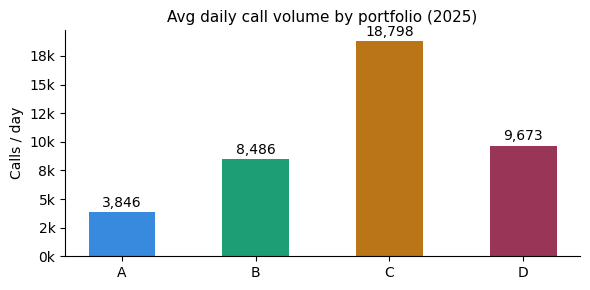

In [18]:
size_rows = []
for p in PORTFOLIOS:
    df = daily[p][daily[p]['year'] == 2025]
    size_rows.append({
        'Portfolio': p,
        'Avg CV/day': round(df['Call Volume'].mean(), 0),
        'Total CV':   int(df['Call Volume'].sum()),
        'Avg CCT (s)':round(df['CCT'].mean(), 1),
        'Avg SL':     f"{df['Service Level'].mean()*100:.1f}%",
        'Avg ABD':    f"{df['Abandon Rate'].mean()*100:.2f}%",
    })
display(pd.DataFrame(size_rows).set_index('Portfolio'))

fig, ax = plt.subplots(figsize=(6, 3))
vals  = [daily[p][daily[p]['year']==2025]['Call Volume'].mean() for p in PORTFOLIOS]
bars  = ax.bar(PORTFOLIOS, vals, color=[COLORS[p] for p in PORTFOLIOS],
               width=0.5, edgecolor='none')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{v:,.0f}', ha='center', va='bottom', fontsize=10)
ax.set_title('Avg daily call volume by portfolio (2025)', fontsize=11)
ax.set_ylabel('Calls / day')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

Day of Week Pattern

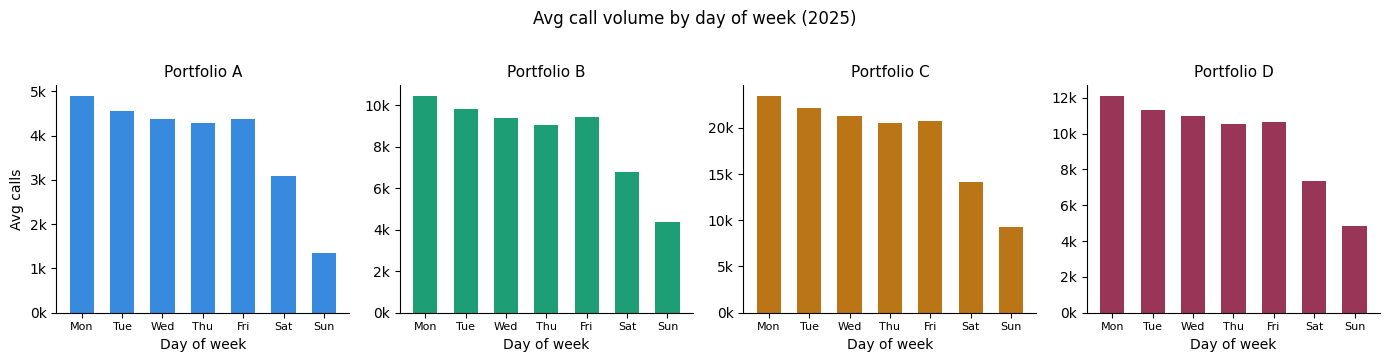

  Portfolio A: 3.7x
  Portfolio B: 2.4x
  Portfolio C: 2.5x
  Portfolio D: 2.5x


In [19]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=False)
dow_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

for ax, p in zip(axes, PORTFOLIOS):
    df = daily[p][daily[p]['year'] == 2025]
    dow_cv = df.groupby('dow_name')['Call Volume'].mean().reindex(dow_order)
    ax.bar(dow_order, dow_cv.values, color=COLORS[p], width=0.6, edgecolor='none')
    ax.set_title(f'Portfolio {p}', fontsize=11)
    ax.set_xlabel('Day of week')
    ax.set_ylabel('Avg calls' if p == 'A' else '')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
    ax.tick_params(axis='x', labelsize=8)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Avg call volume by day of week (2025)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Mon vs Sun ratio
for p in PORTFOLIOS:
    df = daily[p][daily[p]['year'] == 2025]
    mon = df[df['dow_name']=='Mon']['Call Volume'].mean()
    sun = df[df['dow_name']=='Sun']['Call Volume'].mean()
    print(f'  Portfolio {p}: {mon/sun:.1f}x')

CCT Distribution and intra day shape

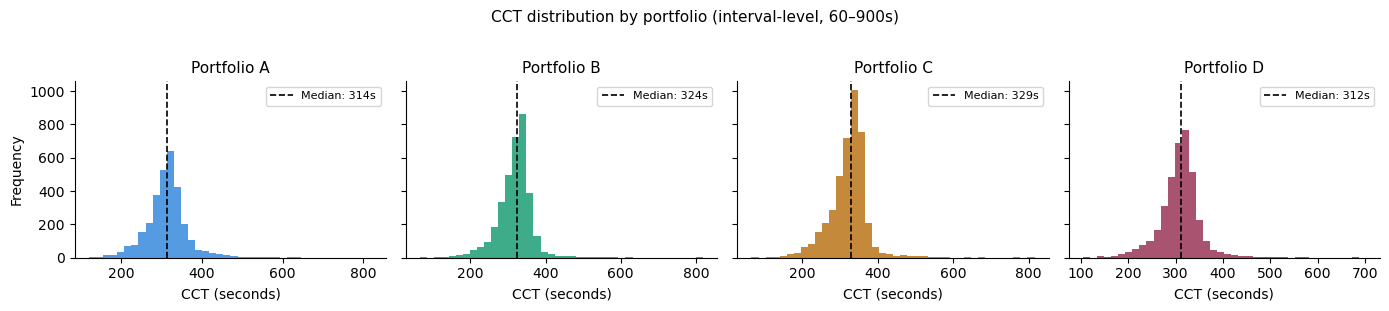

In [14]:
# Distribution of CCT across portfolios
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)

for ax, p in zip(axes, PORTFOLIOS):
    df = interval[p]
    cct = df[(df['CCT'] > 60) & (df['CCT'] < 900) &
             (df['Call Volume'] >= 5)]['CCT']
    ax.hist(cct, bins=40, color=COLORS[p], edgecolor='none', alpha=0.85)
    ax.axvline(cct.median(), color='black', linewidth=1.2, linestyle='--',
               label=f'Median: {cct.median():.0f}s')
    ax.set_title(f'Portfolio {p}', fontsize=11)
    ax.set_xlabel('CCT (seconds)')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

axes[0].set_ylabel('Frequency')
fig.suptitle('CCT distribution by portfolio (interval-level, 60–900s)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

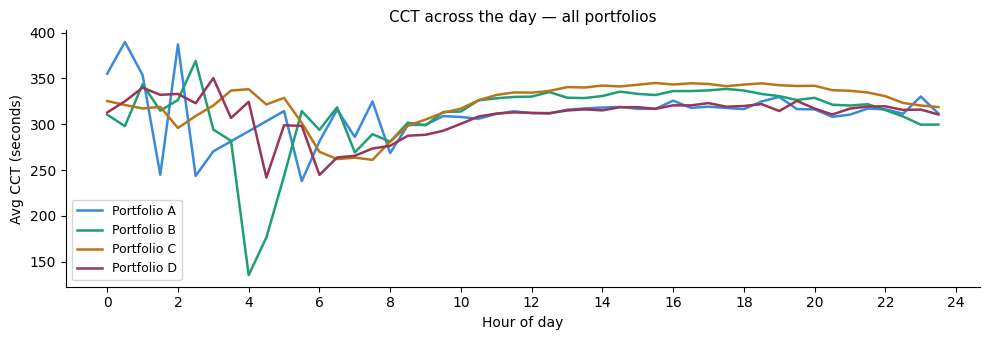

CCT: early morning (6–9am) vs peak afternoon (2–5pm):
  A: morning=297s  afternoon=319s  delta=+22s
  B: morning=292s  afternoon=334s  delta=+43s
  C: morning=277s  afternoon=343s  delta=+66s
  D: morning=272s  afternoon=319s  delta=+47s


In [20]:
# CCT intraday trend
fig, ax = plt.subplots(figsize=(10, 3.5))

for p in PORTFOLIOS:
    df = interval[p]
    df = df[(df['CCT'] > 60) & (df['CCT'] < 900) & (df['Call Volume'] >= 5)].copy()
    df['mins'] = df['mins'].astype(float)
    cct_slot = df.groupby('mins')['CCT'].mean()
    ax.plot(cct_slot.index / 60, cct_slot.values,
            label=f'Portfolio {p}', color=COLORS[p], linewidth=1.8)

ax.set_xlabel('Hour of day')
ax.set_ylabel('Avg CCT (seconds)')
ax.set_title('CCT across the day — all portfolios', fontsize=11)
ax.set_xticks(range(0, 25, 2))
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# Morning low vs afternoon high
print('CCT: early morning (6–9am) vs peak afternoon (2–5pm):')
for p in PORTFOLIOS:
    df = interval[p].copy()
    df = df[(df['CCT']>60) & (df['CCT']<900) & (df['Call Volume']>=5)]
    df['mins'] = df['mins'].astype(float)
    morning   = df[df['mins'].between(360, 540)]['CCT'].mean()
    afternoon = df[df['mins'].between(840, 1020)]['CCT'].mean()
    print(f'  {p}: morning={morning:.0f}s  afternoon={afternoon:.0f}s  delta=+{afternoon-morning:.0f}s')

Abandon Rate

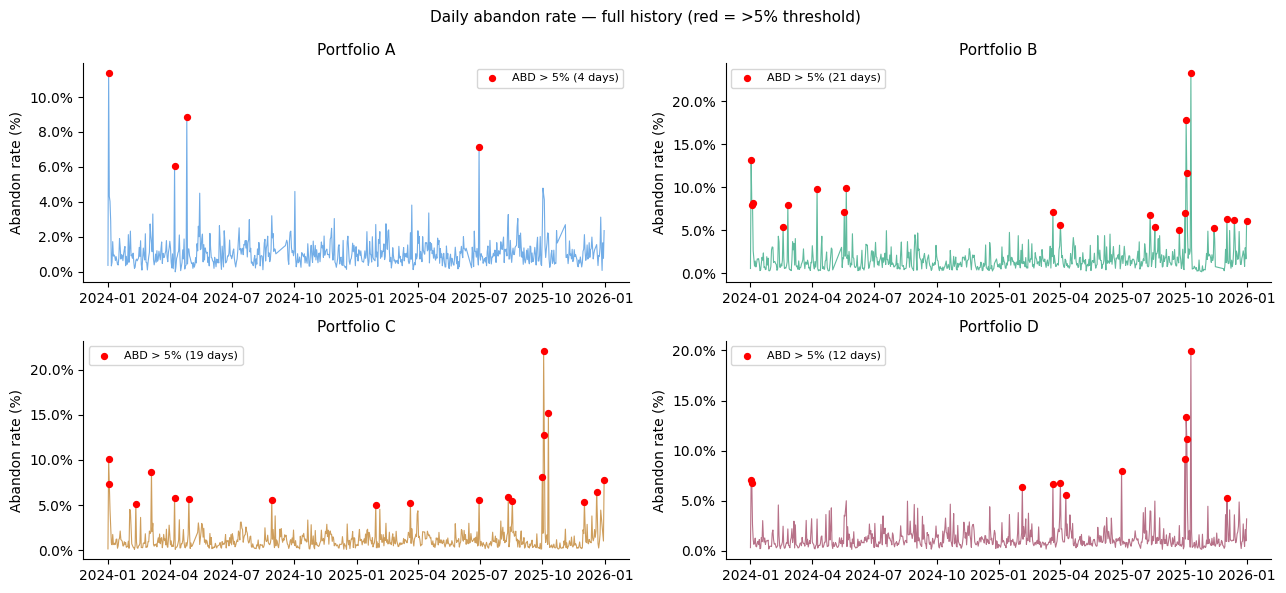


Top 5 highest abandon days per portfolio:

Portfolio A:
      date dow_name  Call Volume Abandon Rate
2024-01-02      Tue     7,458.00       11.36%
2024-04-26      Fri     4,474.00        8.86%
2025-06-30      Mon     4,987.00        7.12%
2024-04-08      Mon     4,937.00        6.08%
2025-10-02      Thu     4,616.00        4.79%

Portfolio B:
      date dow_name  Call Volume Abandon Rate
2025-10-10      Fri     8,859.00       23.27%
2025-10-03      Fri    10,095.00       17.80%
2024-01-02      Tue    14,914.00       13.20%
2025-10-04      Sat     6,365.00       11.71%
2024-05-21      Tue    10,436.00        9.95%

Portfolio C:
      date dow_name  Call Volume Abandon Rate
2025-10-03      Fri    22,658.00       22.09%
2025-10-10      Fri    19,888.00       15.20%
2025-10-04      Sat    14,077.00       12.72%
2024-01-02      Tue    30,738.00       10.05%
2024-03-05      Tue    26,921.00        8.70%

Portfolio D:
      date dow_name  Call Volume Abandon Rate
2025-10-10      Fri    10,2

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharey=False)

for ax, p in zip(axes.flat, PORTFOLIOS):
    df = daily[p].dropna(subset=['Abandon Rate'])
    ax.plot(df['date'], df['Abandon Rate'] * 100,
            color=COLORS[p], linewidth=0.8, alpha=0.7)
    # Mark days above 5% ABD
    spikes = df[df['Abandon Rate'] > 0.05]
    ax.scatter(spikes['date'], spikes['Abandon Rate'] * 100,
               color='red', s=18, zorder=5, label=f'ABD > 5% ({len(spikes)} days)')
    ax.set_title(f'Portfolio {p}', fontsize=11)
    ax.set_ylabel('Abandon rate (%)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}%'))
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Daily abandon rate — full history (red = >5% threshold)', fontsize=11)
plt.tight_layout()
plt.show()

# Top 5 worst abandon days per portfolio
print('\nTop 5 highest abandon days per portfolio:')
for p in PORTFOLIOS:
    top = (daily[p].dropna(subset=['Abandon Rate'])
           .nlargest(5, 'Abandon Rate')
           [['date','dow_name','Call Volume','Abandon Rate']])
    top['Abandon Rate'] = top['Abandon Rate'].apply(lambda x: f'{x*100:.2f}%')
    print(f'\nPortfolio {p}:')
    print(top.to_string(index=False))

interval slot analysis

In [29]:
# Each day should have exactly 48 slots (48 × 30min = 24h)
found_issues = False
for p in PORTFOLIOS:
    counts = (interval[p].dropna(subset=['mins'])
              .groupby(['Month','Day'])
              .size()
              .reset_index(name='slots'))
    bad = counts[counts['slots'] != 48]
    if len(bad):
        found_issues = True
        print(f'\nPortfolio {p} — {len(bad)} incomplete days:')
        print(bad.to_string(index=False))

if not found_issues:
    print('All days have exactly 48 slots')

# Zero-volume slots
print('\nZero-volume slots (CV = 0) by portfolio:')
for p in PORTFOLIOS:
    df = interval[p].dropna(subset=['Call Volume'])
    zeros = (df['Call Volume'] == 0).sum()
    total = len(df)
    print(f'  Portfolio {p}: {zeros:,} / {total:,}  ({zeros/total*100:.1f}%)')


Portfolio A — 86 incomplete days:
Month  Day  slots
April    1     46
April    2     46
April    3     45
April    4     45
April    5     46
April    6     43
April    7     38
April    8     46
April    9     46
April   10     46
April   11     46
April   12     42
April   13     41
April   14     45
April   15     45
April   16     46
April   17     43
April   18     45
April   19     46
April   20     41
April   21     46
April   22     43
April   23     45
April   24     44
April   25     43
April   26     43
April   27     43
April   28     44
April   29     45
April   30     46
 June    1     44
 June    3     47
 June    4     47
 June    5     43
 June    6     46
 June    7     43
 June    8     43
 June    9     45
 June   10     46
 June   11     47
 June   13     46
 June   14     42
 June   15     43
 June   16     42
 June   17     43
 June   18     46
 June   19     46
 June   20     45
 June   21     45
 June   22     46
 June   23     43
 June   24     45
 June   26 

year on year daily cv trend

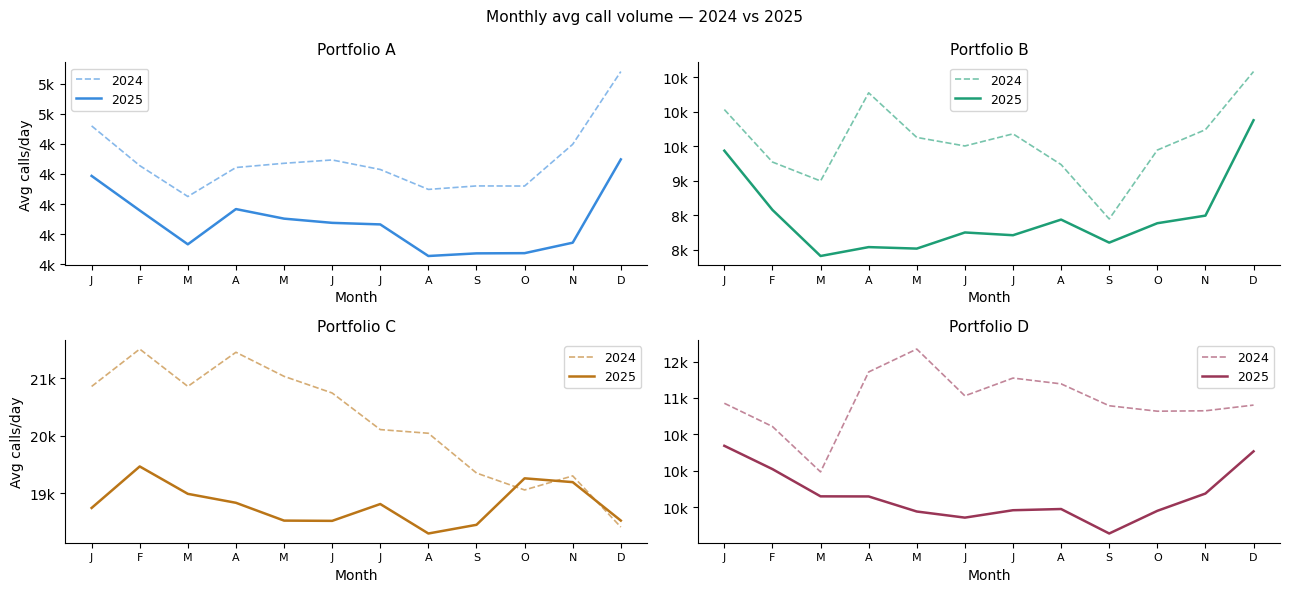

Year-over-year change in avg daily CV (same months, Jan–Jul):
  Portfolio A: 2024=4,331  2025=3,910  YoY=-9.7%
  Portfolio B: 2024=9,630  2025=8,351  YoY=-13.3%
  Portfolio C: 2024=20,924  2025=18,836  YoY=-10.0%
  Portfolio D: 2024=10,980  2025=9,702  YoY=-11.6%


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6))

for ax, p in zip(axes.flat, PORTFOLIOS):
    for yr, ls, lw in [(2024, '--', 1.2), (2025, '-', 1.8)]:
        df = daily[p][daily[p]['year'] == yr].copy()
        monthly = df.groupby('month')['Call Volume'].mean()
        ax.plot(monthly.index, monthly.values,
                label=str(yr), linestyle=ls, linewidth=lw, color=COLORS[p],
                alpha=0.6 if yr == 2024 else 1.0)
    ax.set_title(f'Portfolio {p}', fontsize=11)
    ax.set_xlabel('Month')
    ax.set_ylabel('Avg calls/day' if p in ['A','C'] else '')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Monthly avg call volume — 2024 vs 2025', fontsize=11)
plt.tight_layout()
plt.show()

# YoY change summary
print('Year-over-year change in avg daily CV (same months, Jan–Jul):')
for p in PORTFOLIOS:
    df = daily[p]
    cv24 = df[(df['year']==2024) & (df['month']<=7)]['Call Volume'].mean()
    cv25 = df[(df['year']==2025) & (df['month']<=7)]['Call Volume'].mean()
    print(f'  Portfolio {p}: 2024={cv24:,.0f}  2025={cv25:,.0f}  YoY={((cv25-cv24)/cv24)*100:+.1f}%')

Summary Table

In [20]:
summary = []
for p in PORTFOLIOS:
    d = daily[p][daily[p]['year']==2025].dropna(subset=['Call Volume'])
    iv = interval[p]
    cct_iv = iv[(iv['CCT']>60) & (iv['CCT']<900) & (iv['Call Volume']>=5)]['CCT']
    summary.append({
        'Portfolio'       : p,
        'Avg CV/day'      : f"{d['Call Volume'].mean():,.0f}",
        'CV std'          : f"{d['Call Volume'].std():,.0f}",
        'CV CoV'          : f"{d['Call Volume'].std()/d['Call Volume'].mean()*100:.1f}%",
        'Median CCT (s)'  : f"{cct_iv.median():.0f}",
        'Avg SL'          : f"{d['Service Level'].mean()*100:.1f}%",
        'Avg ABD'         : f"{d['Abandon Rate'].mean()*100:.2f}%",
        'Max ABD day'     : f"{d['Abandon Rate'].max()*100:.1f}%",
        'Days w/ ABD>5%'  : int((d['Abandon Rate'] > 0.05).sum()),
    })

display(pd.DataFrame(summary).set_index('Portfolio'))
print('\nCoV = coefficient of variation (std/mean). Higher = more variable day-to-day.')

,Avg CV/day,CV std,CV CoV,Median CCT (s),Avg SL,Avg ABD,Max ABD day,Days w/ ABD>5%
Portfolio,,,,,,,,
A,"3,846","1,292",33.6%,314,92.2%,1.12%,7.1%,1
B,"8,486","2,352",27.7%,324,88.0%,1.88%,23.3%,13
C,"18,798","5,296",28.2%,329,88.3%,1.32%,22.1%,12
D,"9,673","2,730",28.2%,312,90.6%,1.41%,20.0%,10



CoV = coefficient of variation (std/mean). Higher = more variable day-to-day.


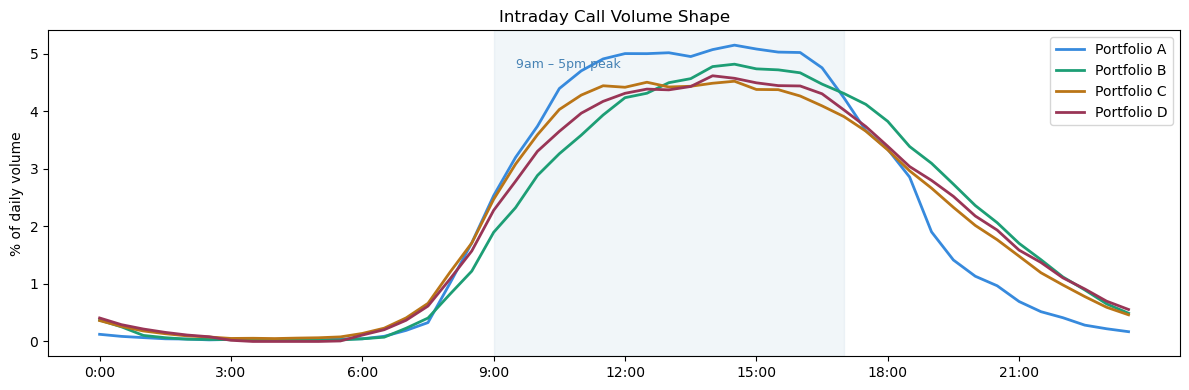

Saved: eda_1_intraday_shape.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

for p in PORTFOLIOS:
    # Weekdays only — the staffing-relevant shape
    iv = iv_train[p][iv_train[p]['dow'] < 5]
    shape = iv.groupby('mins')['cv_frac'].median().reindex(ALL_SLOTS).fillna(0)
    ax.plot(range(len(ALL_SLOTS)), shape.values * 100,
            label=f'Portfolio {p}', color=COLORS[p], linewidth=2)

# Shade peak window
peak_s = next(i for i,m in enumerate(ALL_SLOTS) if m == 540)   # 9am
peak_e = next(i for i,m in enumerate(ALL_SLOTS) if m == 1020)  # 5pm
ax.axvspan(peak_s, peak_e, alpha=0.07, color='steelblue')
ax.text(peak_s + 1, ax.get_ylim()[1] * 0.88, '9am – 5pm peak', fontsize=9, color='steelblue')

tick_idx  = [i for i, m in enumerate(ALL_SLOTS) if m % 180 == 0]
tick_lbls = [SLOT_LABELS[i] for i in tick_idx]
ax.set_xticks(tick_idx)
ax.set_xticklabels(tick_lbls)
ax.set_ylabel('% of daily volume')
ax.set_title('Intraday Call Volume Shape')
ax.legend()
plt.tight_layout()
plt.show()

Day of Week Index

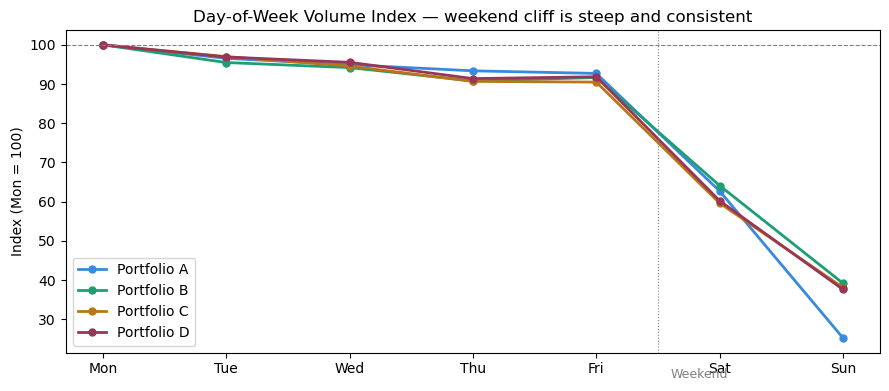

Saved: eda_2_dow_index.png


In [ ]:
DOW_LABELS = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(9, 4))

for p in PORTFOLIOS:
    t = daily[p][(daily[p]['year']==2025) & daily[p]['month'].isin(TRAINING_MONTHS)]
    dow_mean = t.groupby('dow')['Call Volume'].mean()
    base = dow_mean.get(0, 1)   # Monday
    index = [(dow_mean.get(d, np.nan) / base * 100) for d in range(7)]
    ax.plot(range(7), index, marker='o', markersize=5,
            label=f'Portfolio {p}', color=COLORS[p], linewidth=2)

ax.axhline(100, color='grey', linestyle='--', linewidth=0.8)
ax.axvline(4.5, color='grey', linestyle=':', linewidth=0.8)
ax.text(4.6, 15, 'Weekend', fontsize=9, color='grey')
ax.set_xticks(range(7))
ax.set_xticklabels(DOW_LABELS)
ax.set_ylabel('Index (Mon = 100)')
ax.set_title('Day-of-Week Volume Index — weekend cliff is steep and consistent')
ax.legend()
plt.tight_layout()
plt.show()

Service Level vs Abandon Rate

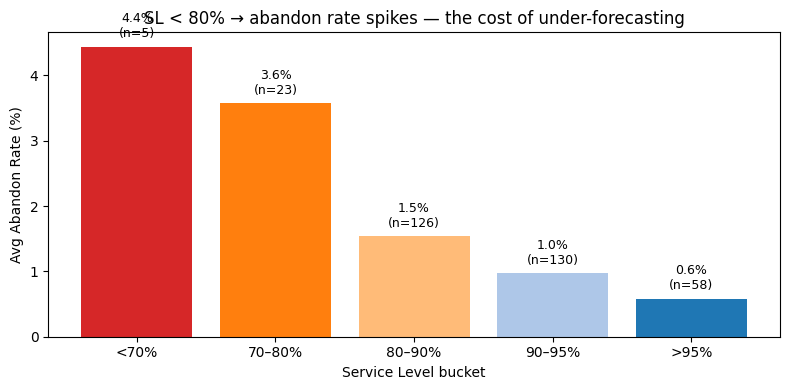

In [22]:
all_daily = []
for p in PORTFOLIOS:
    t = daily[p][(daily[p]['year']==2025) & daily[p]['month'].isin(TRAINING_MONTHS)].copy()
    t['portfolio'] = p
    all_daily.append(t)
all_daily = pd.concat(all_daily, ignore_index=True)

valid = all_daily.dropna(subset=['Service Level','Abandon Rate']).copy()
valid = valid[valid['Service Level'].between(0,1) & valid['Abandon Rate'].between(0,1)]

bins   = [0, 0.70, 0.80, 0.90, 0.95, 1.01]
labels = ['<70%', '70–80%', '80–90%', '90–95%', '>95%']
valid['sl_bucket'] = pd.cut(valid['Service Level'], bins=bins, labels=labels, right=False)

bucket_abd = valid.groupby('sl_bucket', observed=True)['Abandon Rate'].mean() * 100
bucket_n   = valid.groupby('sl_bucket', observed=True).size()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(len(labels)), [bucket_abd.get(l, 0) for l in labels],
              color=['#d62728','#ff7f0e','#ffbb78','#aec7e8','#1f77b4'])

for i, (bar, lbl) in enumerate(zip(bars, labels)):
    n = bucket_n.get(lbl, 0)
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.1,
            f'{h:.1f}%\n(n={n})', ha='center', va='bottom', fontsize=9)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_xlabel('Service Level bucket')
ax.set_ylabel('Avg Abandon Rate (%)')
ax.set_title('SL < 80% → abandon rate spikes — the cost of under-forecasting')
plt.tight_layout()
plt.show()

Monthly Volume Trend (yearly)

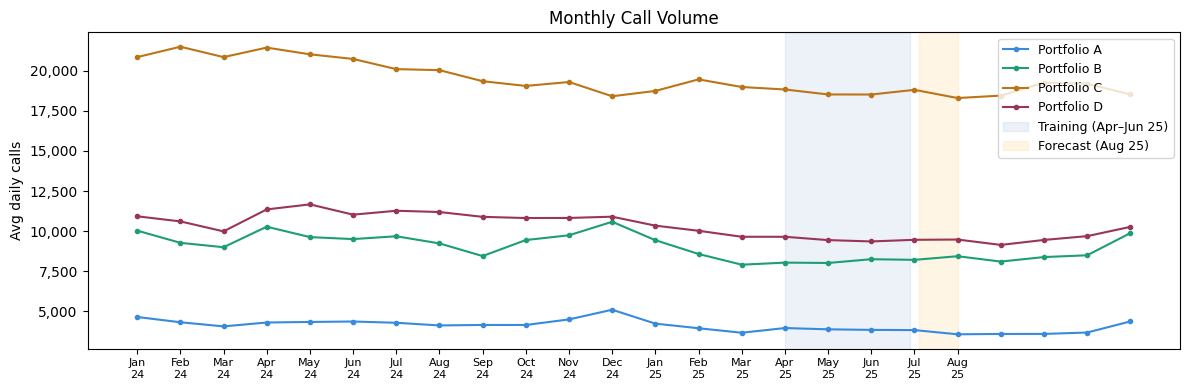

In [23]:
fig, ax = plt.subplots(figsize=(12, 4))

for p in PORTFOLIOS:
    d = daily[p].dropna(subset=['Call Volume'])
    monthly = d.groupby(['year','month'])['Call Volume'].mean().reset_index()
    monthly = monthly[monthly.groupby(['year','month'])['Call Volume'].transform('count') > 0]
    # Create a continuous x-axis: year*12 + month
    monthly['x'] = (monthly['year'] - 2024) * 12 + monthly['month']
    monthly = monthly.sort_values('x')
    ax.plot(monthly['x'], monthly['Call Volume'],
            color=COLORS[p], linewidth=1.5, label=f'Portfolio {p}', marker='o', markersize=3)

all_ym = [(2024,m) for m in range(1,13)] + [(2025,m) for m in range(1,9)]
x_ticks = [(y-2024)*12+m for y,m in all_ym]
x_labels = [f"{MONTH_NAMES[m][:3]}\n{'24' if y==2024 else '25'}" for y,m in all_ym]
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=8)

ax.axvspan((2025-2024)*12+4, (2025-2024)*12+6.9,
           alpha=0.1, color='steelblue', label='Training (Apr–Jun 25)')
ax.axvspan((2025-2024)*12+7.1, (2025-2024)*12+8,
           alpha=0.1, color='orange', label='Forecast (Aug 25)')

ax.set_ylabel('Avg daily calls')
ax.set_title('Monthly Call Volume')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

Final Forecast: August 2025 Daily Call Volume

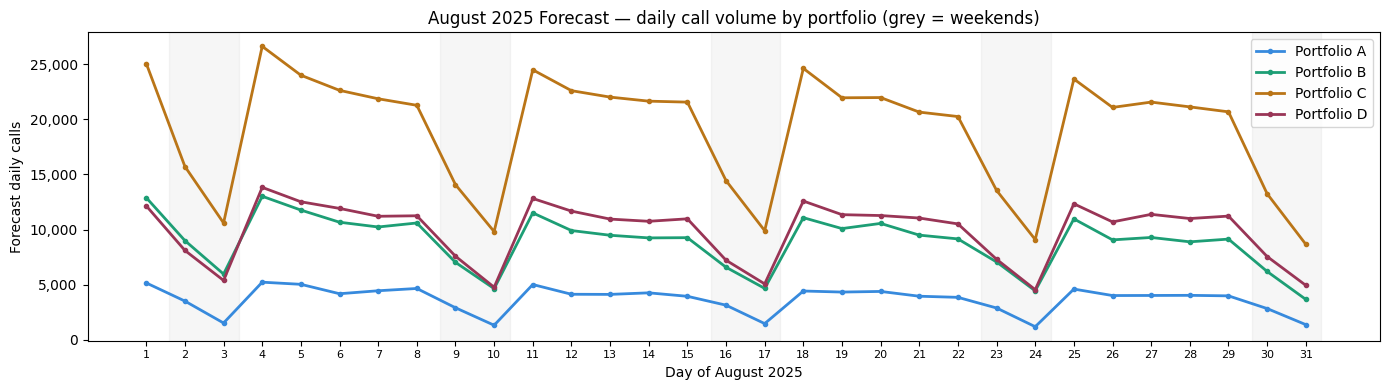

August 2025 forecast summary:
  Portfolio A: 113,797 total | peak day 4 (5,223 calls)
  Portfolio B: 275,474 total | peak day 4 (13,020 calls)
  Portfolio C: 590,498 total | peak day 4 (26,625 calls)
  Portfolio D: 305,872 total | peak day 4 (13,828 calls)


In [24]:
fc = pd.read_csv(FORECAST_CSV)

daily_fc = {}
for p in PORTFOLIOS:
    col = f'Calls_Offered_{p}'
    if col in fc.columns:
        daily_fc[p] = fc.groupby('Day')[col].sum()

fig, ax = plt.subplots(figsize=(14, 4))

for p in PORTFOLIOS:
    if p not in daily_fc: continue
    s = daily_fc[p].sort_index()
    ax.plot(s.index, s.values, color=COLORS[p], linewidth=2,
            marker='o', markersize=3, label=f'Portfolio {p}')

for start in [2, 9, 16, 23, 30]:
    end = min(start + 1, 31)
    ax.axvspan(start - 0.4, end + 0.4, alpha=0.07, color='grey')

ax.set_xticks(range(1, 32))
ax.set_xticklabels(range(1, 32), fontsize=8)
ax.set_xlabel('Day of August 2025')
ax.set_ylabel('Forecast daily calls')
ax.set_title('August 2025 Forecast — daily call volume by portfolio (grey = weekends)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

# Summary table
print('August 2025 forecast summary:')
for p in PORTFOLIOS:
    if p in daily_fc:
        total = daily_fc[p].sum()
        peak_day = daily_fc[p].idxmax()
        print(f'  Portfolio {p}: {total:,.0f} total | peak day {peak_day} ({daily_fc[p].max():,.0f} calls)')